Data Loading and Exploration

In [4]:
from datasets import load_dataset

Loading the dataset from HuggingFace

In [ ]:
ds = load_dataset("coastalchp/ledgar")


In [8]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})

In [10]:
#Excerpt of the dataset from train folder
ds['train'][:10]

{'text': ['Except as otherwise set forth in this Debenture, the Company, for itself and its legal representatives, successors assigns, expressly waives presentment, protest, demand, notice of dishonor, nonpayment, maturity, presentment purpose accelerating diligence collection.',
  'No ERISA Event has occurred or is reasonably expected to occur that, when taken together with all other such Events for which liability occur, could be result in a Material Adverse Effect. Neither Borrower nor any Affiliate maintains contributes obligation maintain contribute Multiemployer Plan Plan, otherwise under Title IV of ERISA.',
  'This Amendment may be executed by one or more of the parties hereto on any number separate counterparts, and all said counterparts taken together shall deemed to constitute same instrument. delivered facsimile other electronic transmission relevant signature pages hereof.',
  'From time to time, as and when required by the Surviving Corporation or its successors assigns, 

Defining Each Split and Converting to Pandas DF

In [31]:
train_df = ds['train'].to_pandas()
test_ds= ds['test'].to_pandas()
validation_ds = ds['validation'].to_pandas()

In [32]:
train_df.head()

,text,label
0,Except as otherwise set forth in this Debentur...,97
1,No ERISA Event has occurred or is reasonably e...,39
2,This Amendment may be executed by one or more ...,26
3,"From time to time, as and when required by the...",45
4,"Commencing March 7, 2016 and during the Employ...",11


In [34]:
train_df.isnull().sum()

#No null values in the dataset

text     0
label    0
dtype: int64

In [36]:
train_df.dtypes

text       str
label    int64
dtype: object

Analyzing Label distribution and Understanding Class Imbalance

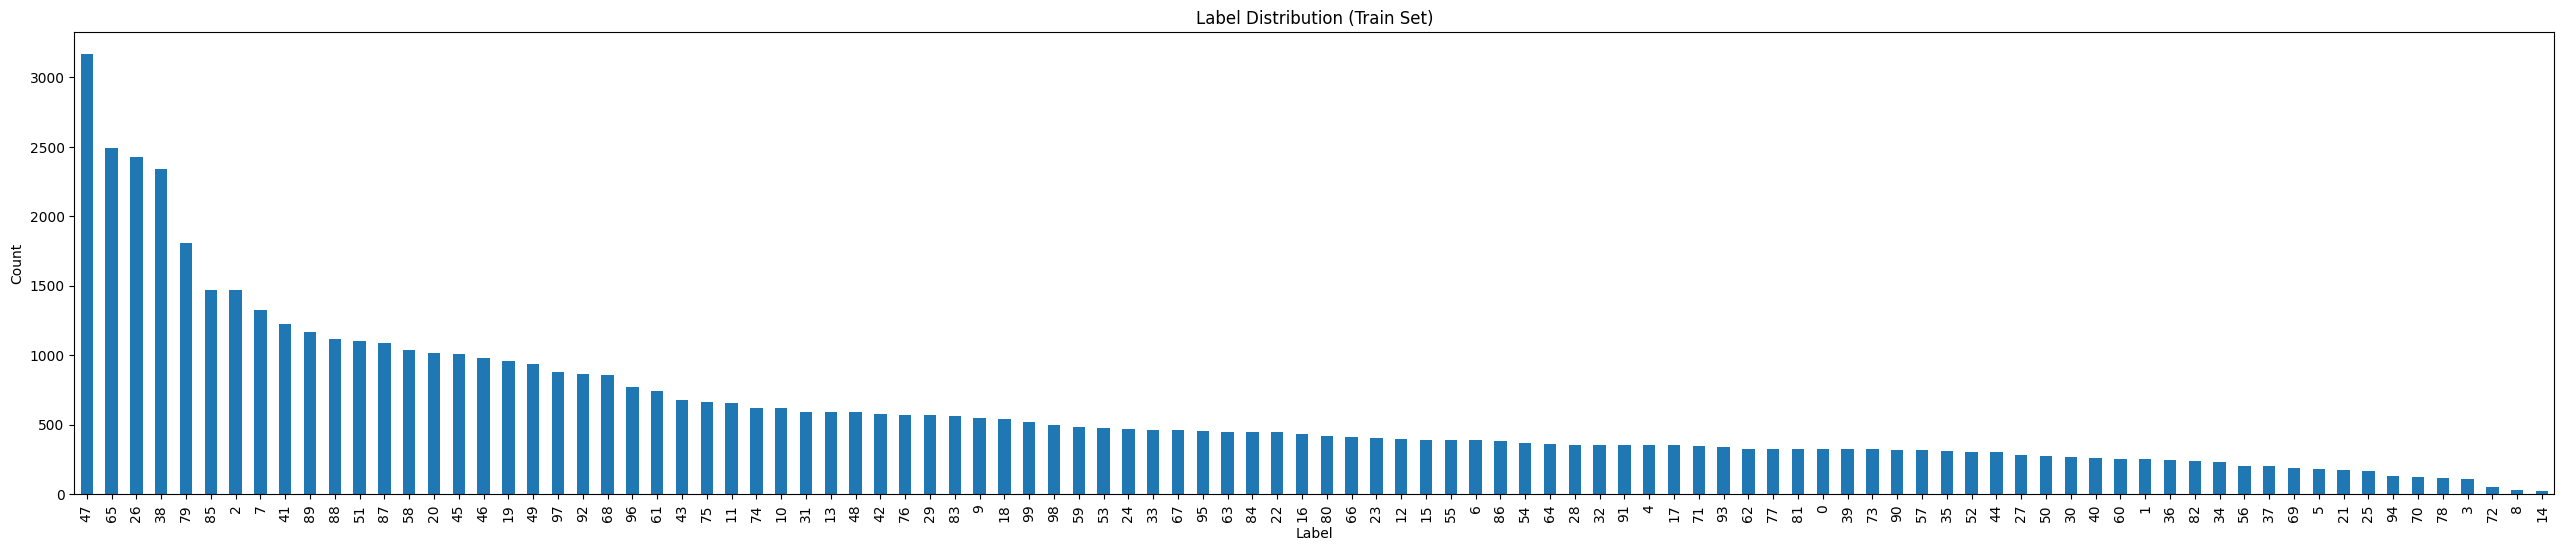

In [42]:
import matplotlib.pyplot as plt

label_counts = train_df['label'].value_counts()

plt.figure(figsize=(32,6))
label_counts.plot(kind='bar')
plt.title("Label Distribution (Train Set)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [53]:
label_counts.describe()

count     100.000000
mean      600.000000
std       538.173811
min        23.000000
25%       311.750000
50%       426.500000
75%       667.250000
max      3167.000000
Name: count, dtype: float64

In [49]:
label_counts.head(10)

label
47    3167
65    2493
26    2427
38    2340
79    1808
85    1469
2     1467
7     1327
41    1224
89    1166
Name: count, dtype: int64

In [44]:
#Checking number of Unique Classes
num_classes = train_df['label'].nunique()
print(num_classes)

100


In [45]:
#Understanding text length
train_df['text_length'] = train_df['text'].apply(len)
train_df['text_length'].describe()

count    60000.000000
mean       465.333817
std        315.083852
min         18.000000
25%        239.000000
50%        386.000000
75%        602.000000
max       3947.000000
Name: text_length, dtype: float64

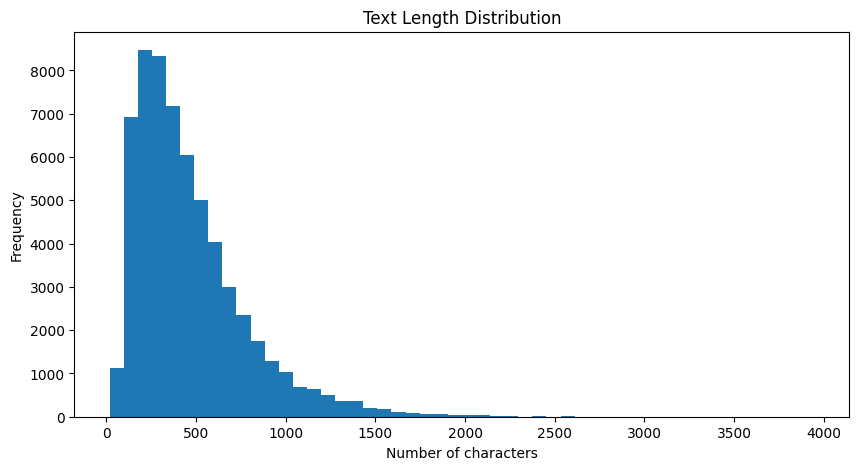

In [47]:
plt.figure(figsize=(10,5))
plt.hist(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

#### Ultimate Systematic Problem: Multi Class Text Classification

In [52]:
print("Head end")
print(label_counts.head(10))
print("Tail end")
print(label_counts.tail(10))

Head end
label
47    3167
65    2493
26    2427
38    2340
79    1808
85    1469
2     1467
7     1327
41    1224
89    1166
Name: count, dtype: int64
Tail end
label
5     178
21    175
25    168
94    131
70    125
78    118
3     106
72     47
8      31
14     23
Name: count, dtype: int64


Apply Class Weights

In [55]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes =np.unique(train_df['label'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'])
class_weights = dict(zip(classes, weights))

In [58]:
for cls, w in class_weights.items():
    print(f"Class {cls}: {w:.2f}")

Class 0: 1.84
Class 1: 2.38
Class 2: 0.41
Class 3: 5.66
Class 4: 1.70
Class 5: 3.37
Class 6: 1.56
Class 7: 0.45
Class 8: 19.35
Class 9: 1.09
Class 10: 0.97
Class 11: 0.91
Class 12: 1.51
Class 13: 1.02
Class 14: 26.09
Class 15: 1.54
Class 16: 1.38
Class 17: 1.72
Class 18: 1.11
Class 19: 0.62
Class 20: 0.59
Class 21: 3.43
Class 22: 1.35
Class 23: 1.48
Class 24: 1.28
Class 25: 3.57
Class 26: 0.25
Class 27: 2.16
Class 28: 1.69
Class 29: 1.06
Class 30: 2.28
Class 31: 1.02
Class 32: 1.69
Class 33: 1.30
Class 34: 2.62
Class 35: 1.95
Class 36: 2.46
Class 37: 2.99
Class 38: 0.26
Class 39: 1.85
Class 40: 2.33
Class 41: 0.49
Class 42: 1.04
Class 43: 0.89
Class 44: 2.00
Class 45: 0.59
Class 46: 0.61
Class 47: 0.19
Class 48: 1.02
Class 49: 0.64
Class 50: 2.21
Class 51: 0.54
Class 52: 1.97
Class 53: 1.27
Class 54: 1.64
Class 55: 1.55
Class 56: 2.97
Class 57: 1.92
Class 58: 0.58
Class 59: 1.25
Class 60: 2.35
Class 61: 0.81
Class 62: 1.83
Class 63: 1.35
Class 64: 1.65
Class 65: 0.24
Class 66: 1.47
Cla

In [60]:
class_weights = {int(k): float(v) for k, v in class_weights.items()}

In [64]:
import json

with open("class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=4)